In [2]:
import pandas as pd

sentiment = pd.read_csv("/content/fear_greed_index (1).csv")
trades = pd.read_csv("/content/historical_data (1).csv")

In [3]:
sentiment.head()


,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [4]:
trades.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.003055,1.050000e+15,1.730000e+12


In [5]:
print(sentiment.isnull().sum())
print(trades.isnull().sum())

timestamp         0
value             0
classification    0
date              0
dtype: int64
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          1
Transaction Hash    1
Order ID            1
Crossed             1
Fee                 1
Trade ID            1
Timestamp           1
dtype: int64


In [6]:
trades['Timestamp IST'] = pd.to_datetime(trades['Timestamp IST'], format='%d-%m-%Y %H:%M')
trades['date'] = trades['Timestamp IST'].dt.date
sentiment['date'] = pd.to_datetime(sentiment['date']).dt.date

In [7]:
merged = pd.merge(trades, sentiment, on='date', how='left')

In [8]:
# 4. CREATE METRICS
# ================================

# Daily Profit
daily_pnl = merged.groupby('date')['Closed PnL'].sum()

# Number of trades
trades_per_day = merged.groupby('date').size()

# Average trade size
avg_size = merged.groupby('date')['Size USD'].mean()

# Win rate
merged['win'] = merged['Closed PnL'] > 0
win_rate = merged.groupby('date')['win'].mean()
# Combine all metrics
summary = pd.DataFrame({
    'Daily Profit': daily_pnl,
    'Trades': trades_per_day,
    'Avg Size': avg_size,
    'Win Rate': win_rate
})

print("\n📊 DAILY SUMMARY:\n")
print(summary.head())




📊 DAILY SUMMARY:

            Daily Profit  Trades      Avg Size  Win Rate
date                                                    
2024-04-20      0.000000      20   2436.682500       0.0
2024-04-25      0.000000      68    753.851029       0.0
2024-06-19      0.000000       3   7722.796667       0.0
2024-06-20  57478.456026       8  21188.468750       1.0
2024-07-23  88084.992348     229   1072.259563       1.0


In [9]:
# 5. ANALYSIS QUESTIONS
# ================================

print("\n❓ Q1: Profit in FEAR vs GREED")
print(merged.groupby('classification')['Closed PnL'].mean())

print("\n❓ Q2: Average trade size in FEAR vs GREED")
print(merged.groupby('classification')['Size USD'].mean())

print("\n❓ Q3: Win rate in FEAR vs GREED")
print(merged.groupby('classification')['win'].mean())

print("\n❓ Q4: Number of trades in FEAR vs GREED")
print(merged.groupby('classification').size())


❓ Q1: Profit in FEAR vs GREED
classification
Extreme Fear     338.916162
Extreme Greed     65.938570
Fear             194.770442
Greed            136.216495
Neutral          178.839679
Name: Closed PnL, dtype: float64

❓ Q2: Average trade size in FEAR vs GREED
classification
Extreme Fear      7681.766118
Extreme Greed     8437.322281
Fear             30507.735890
Greed            28036.998658
Neutral          25814.644156
Name: Size USD, dtype: float64

❓ Q3: Win rate in FEAR vs GREED
classification
Extreme Fear     0.322624
Extreme Greed    0.115000
Fear             0.415617
Greed            0.350380
Neutral          0.542618
Name: win, dtype: float64

❓ Q4: Number of trades in FEAR vs GREED
classification
Extreme Fear      747
Extreme Greed    1600
Fear             8414
Greed            4732
Neutral          3109
dtype: int64


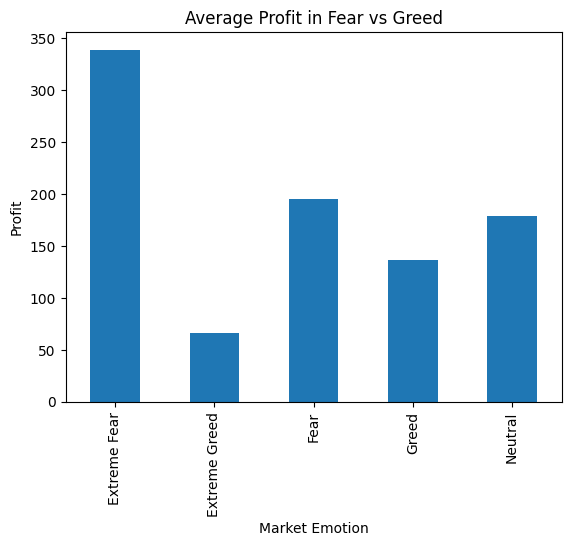

In [10]:
# 6. VISUALIZATION
# ================================
import matplotlib.pyplot as plt
# Profit comparison
merged.groupby('classification')['Closed PnL'].mean().plot(kind='bar')
plt.title("Average Profit in Fear vs Greed")
plt.xlabel("Market Emotion")
plt.ylabel("Profit")
plt.show()


In [11]:
merged['win'] = merged['Closed PnL'] > 0


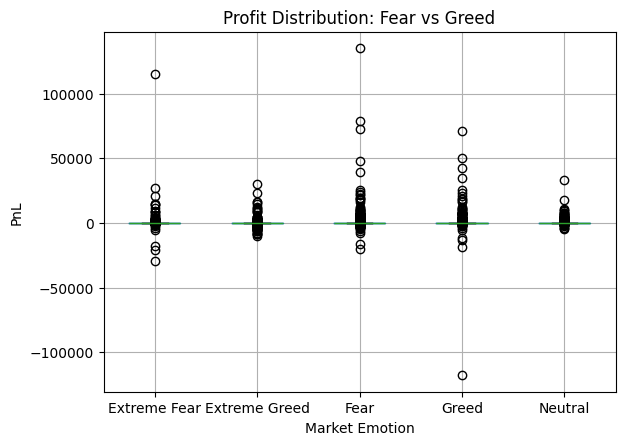

In [12]:
merged.boxplot(column='Closed PnL', by='classification')
plt.title("Profit Distribution: Fear vs Greed")
plt.suptitle("")
plt.xlabel("Market Emotion")
plt.ylabel("PnL")
plt.show()

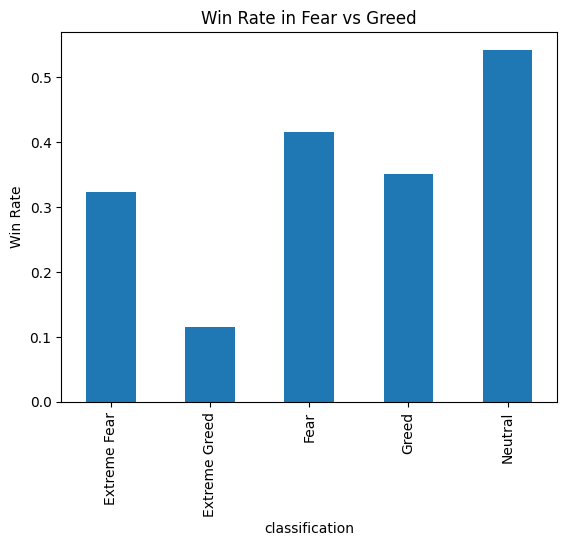

In [13]:
merged.groupby('classification')['win'].mean().plot(kind='bar')
plt.title("Win Rate in Fear vs Greed")
plt.ylabel("Win Rate")
plt.show()

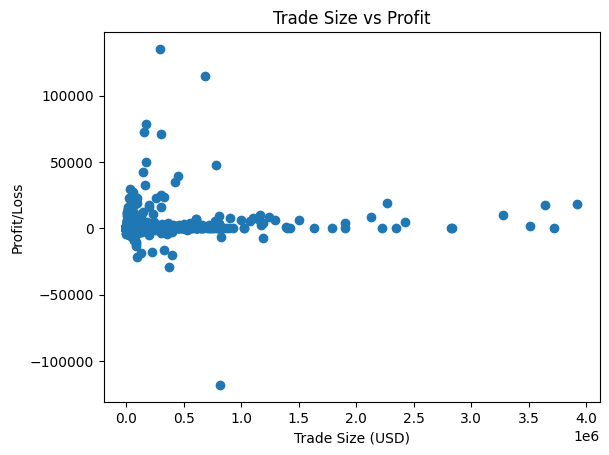

In [14]:
plt.scatter(merged['Size USD'], merged['Closed PnL'])
plt.xlabel("Trade Size (USD)")
plt.ylabel("Profit/Loss")
plt.title("Trade Size vs Profit")
plt.show()

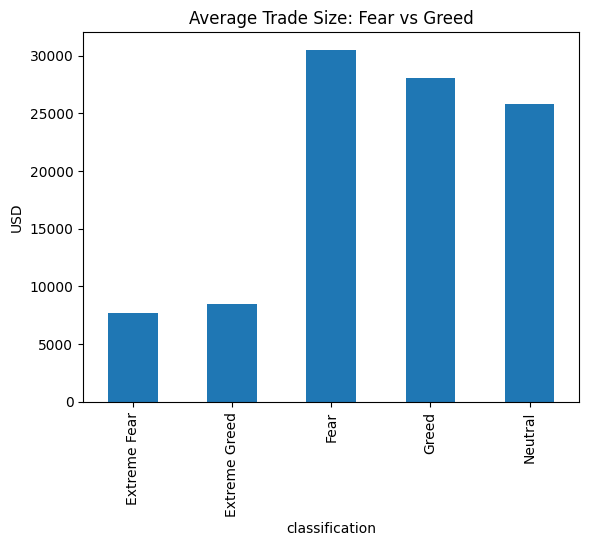

In [15]:
merged.groupby('classification')['Size USD'].mean().plot(kind='bar')
plt.title("Average Trade Size: Fear vs Greed")
plt.ylabel("USD")
plt.show()

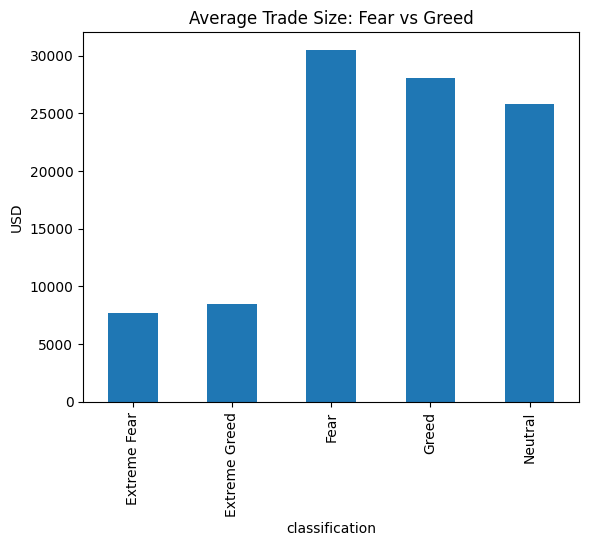

In [16]:
merged.groupby('classification')['Size USD'].mean().plot(kind='bar')
plt.title("Average Trade Size: Fear vs Greed")
plt.ylabel("USD")
plt.show()

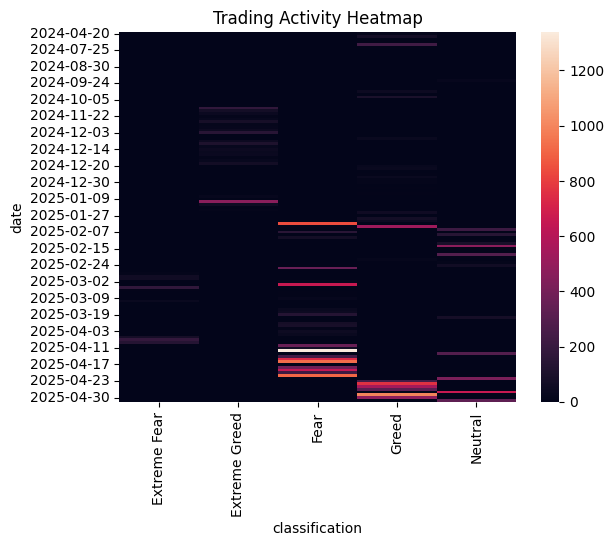

In [17]:
import seaborn as sns

activity = merged.groupby(['date','classification']).size().unstack()

sns.heatmap(activity.fillna(0))
plt.title("Trading Activity Heatmap")
plt.show()

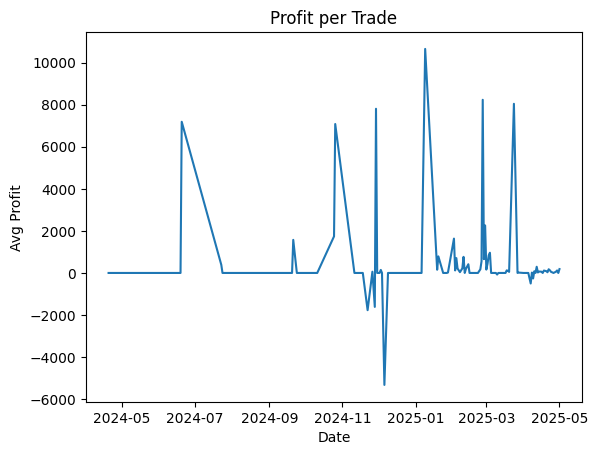

In [18]:
profit_per_trade = merged.groupby('date')['Closed PnL'].mean()

profit_per_trade.plot()
plt.title("Profit per Trade")
plt.xlabel("Date")
plt.ylabel("Avg Profit")
plt.show()

In [19]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

# ================================
# 1. LOAD DATA
# ================================

sentiment = pd.read_csv("/content/fear_greed_index (1).csv")
trades = pd.read_csv("/content/historical_data (1).csv")

# ================================
# 2. CLEAN COLUMN NAMES (IMPORTANT 🔥)
# ================================

sentiment.columns = sentiment.columns.str.strip().str.lower()
trades.columns = trades.columns.str.strip().str.lower()

print("Sentiment columns:", sentiment.columns)
print("Trades columns:", trades.columns)

# ================================
# 3. FIX DATE COLUMNS
# ================================

sentiment['date'] = pd.to_datetime(sentiment['date']).dt.date
trades['timestamp ist'] = pd.to_datetime(trades['timestamp ist'], format='%d-%m-%Y %H:%M')
trades['date'] = trades['timestamp ist'].dt.date

# ================================
# 4. MERGE DATA
# ================================

merged = pd.merge(trades, sentiment, on='date', how='left')

# ================================
# 5. TARGET VARIABLE
# ================================

merged['target'] = (merged['closed pnl'] > 0).astype(int)

# ================================
# 6. FEATURE ENGINEERING
# ================================

merged['size_price_ratio'] = merged['size usd'] / (merged['execution price'] + 1)
merged['fee_ratio'] = merged['fee'] / (merged['size usd'] + 1)

merged['hour'] = pd.to_datetime(merged['timestamp ist']).dt.hour
merged['day_of_week'] = pd.to_datetime(merged['timestamp ist']).dt.dayofweek

# ================================
# 7. SELECT FEATURES
# ================================

num_features = [
    'size usd',
    'execution price',
    'fee',
    'size_price_ratio',
    'fee_ratio',
    'hour',
    'day_of_week'
]

cat_features = [
    'side',
    'direction',
    'classification'   # ✅ fixed (small c)
]

# Drop missing
data = merged[num_features + cat_features + ['target']].dropna()

X = data[num_features + cat_features]
y = data['target']

# ================================
# 8. PREPROCESSING PIPELINE
# ================================

num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_features),
    ('cat', cat_pipeline, cat_features)
])

# ================================
# 9. MODEL
# ================================

model = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    min_samples_split=10,
    random_state=42
)

pipeline = Pipeline([
    ('prep', preprocessor),
    ('model', model)
])

# ================================
# 10. TRAIN TEST SPLIT
# ================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ================================
# 11. TRAIN
# ================================

pipeline.fit(X_train, y_train)

# ================================
# 12. PREDICT
# ================================

y_pred = pipeline.predict(X_test)
y_prob = pipeline.predict_proba(X_test)[:, 1]

# ================================
# 13. EVALUATION
# ================================

print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# ================================
# 14. FEATURE IMPORTANCE
# ================================

ohe = pipeline.named_steps['prep'].named_transformers_['cat'].named_steps['onehot']
cat_names = ohe.get_feature_names_out(cat_features)

all_features = num_features + list(cat_names)

importances = pipeline.named_steps['model'].feature_importances_

feature_importance = pd.Series(importances, index=all_features).sort_values(ascending=False)

print("\nTop Features:\n")
print(feature_importance.head(10))

# ================================
# 15. SAMPLE PREDICTION
# ================================

sample = X_test.iloc[[0]]
prob = pipeline.predict_proba(sample)[0][1]

print("\nExample Trade Profit Probability:", round(prob, 2))

/tmp/ipykernel_12371/1402502580.py:17: DtypeWarning: Columns (12) have mixed types. Specify dtype option on import or set low_memory=False.
  trades = pd.read_csv("/content/historical_data (1).csv")


Sentiment columns: Index(['timestamp', 'value', 'classification', 'date'], dtype='object')
Trades columns: Index(['account', 'coin', 'execution price', 'size tokens', 'size usd', 'side',
       'timestamp ist', 'start position', 'direction', 'closed pnl',
       'transaction hash', 'order id', 'crossed', 'fee', 'trade id',
       'timestamp'],
      dtype='object')

Accuracy: 0.956744374073575
ROC-AUC: 0.9965915041416858

Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.92      0.96      3893
           1       0.92      1.00      0.96      3528

    accuracy                           0.96      7421
   macro avg       0.96      0.96      0.96      7421
weighted avg       0.96      0.96      0.96      7421


Top Features:

direction_Close Long     0.213087
direction_Open Long      0.163598
direction_Open Short     0.158419
direction_Close Short    0.149654
execution price          0.059241
side_BUY                 0.054299
sid

In [20]:
# ================================
# 16. MANUAL INPUT TEST
# ================================

new_trade = pd.DataFrame([{
    'size usd': 1000,
    'execution price': 30000,
    'fee': 10,
    'size_price_ratio': 1000 / (30000 + 1),
    'fee_ratio': 10 / (1000 + 1),
    'hour': 14,
    'day_of_week': 2,
    'side': 'BUY',
    'direction': 'LONG',
    'classification': 'Greed'   # or Fear
}])

prob = pipeline.predict_proba(new_trade)[0][1]

print("\n🔮 Prediction for New Trade:")
print("Probability of Profit:", round(prob, 2))

if prob > 0.6:
    print("✅ GOOD TRADE (High chance of profit)")
elif prob > 0.4:
    print("⚠️ MEDIUM RISK")
else:
    print("❌ HIGH RISK (Avoid)")


🔮 Prediction for New Trade:
Probability of Profit: 0.32
❌ HIGH RISK (Avoid)


In [21]:
# ================================
# 17. USER INPUT VERSION
# ================================

size = float(input("Enter trade size (USD): "))
price = float(input("Enter execution price: "))
fee = float(input("Enter fee: "))
side = input("Enter side (BUY/SELL): ")
direction = input("Enter direction (LONG/SHORT): ")
emotion = input("Enter market emotion (Fear/Greed): ")

new_trade = pd.DataFrame([{
    'size usd': size,
    'execution price': price,
    'fee': fee,
    'size_price_ratio': size / (price + 1),
    'fee_ratio': fee / (size + 1),
    'hour': 12,  # default
    'day_of_week': 2,  # default
    'side': side,
    'direction': direction,
    'classification': emotion
}])

prob = pipeline.predict_proba(new_trade)[0][1]

print("\n🔮 Prediction:")
print("Profit Probability:", round(prob, 2))

Enter trade size (USD): 200
Enter execution price: 400
Enter fee: 220
Enter side (BUY/SELL): sell
Enter direction (LONG/SHORT): long
Enter market emotion (Fear/Greed): greed

🔮 Prediction:
Profit Probability: 0.41


In [22]:
# ================================
# 18. TEST MULTIPLE SCENARIOS
# ================================

test_data = pd.DataFrame([
    {'size usd': 500, 'execution price': 25000, 'fee': 5, 'side': 'BUY', 'direction': 'LONG', 'classification': 'Fear'},
    {'size usd': 2000, 'execution price': 30000, 'fee': 20, 'side': 'BUY', 'direction': 'LONG', 'classification': 'Greed'},
    {'size usd': 800, 'execution price': 28000, 'fee': 8, 'side': 'SELL', 'direction': 'SHORT', 'classification': 'Fear'}
])

# Add engineered features
test_data['size_price_ratio'] = test_data['size usd'] / (test_data['execution price'] + 1)
test_data['fee_ratio'] = test_data['fee'] / (test_data['size usd'] + 1)
test_data['hour'] = 12
test_data['day_of_week'] = 2

probs = pipeline.predict_proba(test_data)[:, 1]

test_data['profit_probability'] = probs

print("\n📊 Multiple Trade Predictions:\n")
print(test_data)


📊 Multiple Trade Predictions:

   size usd  execution price  fee  side direction classification  \
0       500            25000    5   BUY      LONG           Fear   
1      2000            30000   20   BUY      LONG          Greed   
2       800            28000    8  SELL     SHORT           Fear   

   size_price_ratio  fee_ratio  hour  day_of_week  profit_probability  
0          0.019999   0.009980    12            2            0.298449  
1          0.066664   0.009995    12            2            0.318838  
2          0.028570   0.009988    12            2            0.453201  


In [23]:
# ================================
# RISK SCORE SYSTEM 🔥
# ================================

def calculate_risk_score(input_df, model_pipeline):

    df = input_df.copy()

    # Predict probability of profit
    prob = model_pipeline.predict_proba(df)[:, 1]

    # ----------------------------
    # 1. MODEL RISK (MOST IMPORTANT)
    # ----------------------------
    model_risk = (1 - prob) * 100   # higher = risky

    # ----------------------------
    # 2. SIZE RISK
    # ----------------------------
    size_norm = df['size usd'] / df['size usd'].max()
    size_risk = size_norm * 100

    # ----------------------------
    # 3. FEE RISK
    # ----------------------------
    fee_norm = df['fee'] / (df['size usd'] + 1)
    fee_risk = fee_norm * 100

    # ----------------------------
    # 4. EMOTION RISK
    # ----------------------------
    emotion_risk = df['classification'].apply(
        lambda x: 70 if str(x).lower() == 'greed' else 40
    )

    # ----------------------------
    # FINAL WEIGHTED SCORE
    # ----------------------------
    risk_score = (
        0.5 * model_risk +   # ML prediction
        0.2 * size_risk +
        0.2 * fee_risk +
        0.1 * emotion_risk
    )

    return risk_score.round(2), prob.round(2)

In [24]:
# ================================
# TEST RISK SYSTEM
# ================================

test_trade = pd.DataFrame([{
    'size usd': 1500,
    'execution price': 30000,
    'fee': 15,
    'size_price_ratio': 1500 / (30000 + 1),
    'fee_ratio': 15 / (1500 + 1),
    'hour': 14,
    'day_of_week': 2,
    'side': 'BUY',
    'direction': 'LONG',
    'classification': 'Greed'
}])

risk_score, prob = calculate_risk_score(test_trade, pipeline)

print("\n🔮 Trade Analysis:")
print("Profit Probability:", prob[0])
print("Risk Score:", risk_score[0])

# Decision
if risk_score[0] < 30:
    print("✅ LOW RISK → Good trade")
elif risk_score[0] < 60:
    print("⚠️ MEDIUM RISK → Be careful")
else:
    print("❌ HIGH RISK → Avoid trade")


🔮 Trade Analysis:
Profit Probability: 0.33
Risk Score: 60.89
❌ HIGH RISK → Avoid trade
